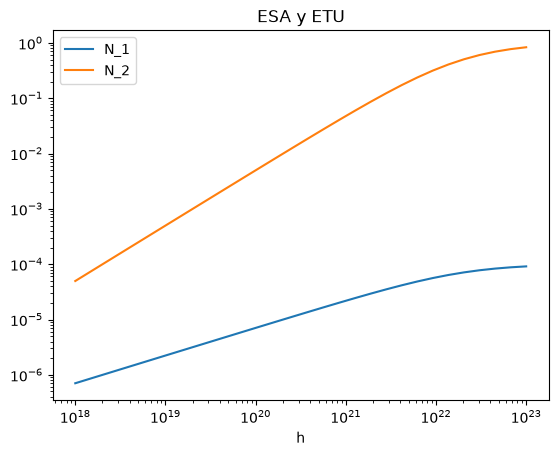

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pint
from poincare import Simulator, SteadyState

from jablonski import Parameter, SingletState, SpectroscopicSystem, assign, initial
from jablonski.transitions import Absorption, EnergyTransferUpconversion, Fluorescence

u = pint.get_application_registry()


class ETU_ESA(SpectroscopicSystem):
    N_0: SingletState = initial(energy=0 * u.eV, default=1)
    N_1: SingletState = initial(energy=1 * u.eV, default=0)
    N_2: SingletState = initial(energy=2 * u.eV, default=0)
    ETU_rate: Parameter = assign(default=1e15 / u.s)
    ESA_rate: Parameter = assign(default=1e-15 * u.cm**2)
    h: Parameter = assign(default=0 / (u.cm**2 * u.s))
    a1 = Absorption(ground=N_0, excited=N_1, rate=1e-15 * u.cm**2, pump=h)
    a2 = Absorption(ground=N_1, excited=N_2, rate=ESA_rate, pump=h)
    f1 = Fluorescence(ground=N_0, excited=N_1, rate=1e7 / u.s)
    f2 = Fluorescence(ground=N_0, excited=N_2, rate=1e7 / u.s)
    etu = EnergyTransferUpconversion(
        sensitizer=N_1, activator=N_2, relaxator=N_0, rate=ETU_rate
    )


sim = Simulator(ETU_ESA)
steady = SteadyState()
result = steady.sweep(
    sim, variable=ETU_ESA.h, values=np.logspace(18, 23, 30) / (u.cm**2 * u.s)
)
result[["N_1", "N_2"]].to_dataframe().plot()
plt.xscale("log")
plt.yscale("log")
plt.title("ESA y ETU")
plt.show()

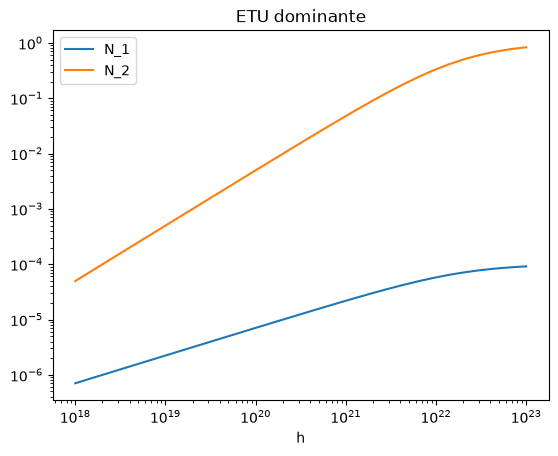

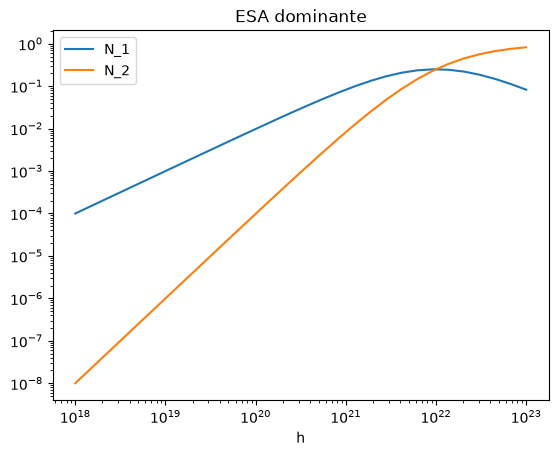

In [2]:
sim_etu_dominante = Simulator(ETU_ESA(ESA_rate=0 * u.cm**2))
sim_esa_dominante = Simulator(ETU_ESA(ETU_rate=0 / u.s))
values = np.logspace(18, 23, 30) / (u.cm**2 * u.s)
etu_dominante = steady.sweep(sim_etu_dominante, variable=ETU_ESA.h, values=values)
esa_dominante = steady.sweep(sim_esa_dominante, variable=ETU_ESA.h, values=values)
etu_dominante[["N_1", "N_2"]].to_dataframe().plot()
plt.title("ETU dominante")
plt.xscale("log")
plt.yscale("log")
plt.show()
esa_dominante[["N_1", "N_2"]].to_dataframe().plot()
plt.title("ESA dominante")
plt.xscale("log")
plt.yscale("log")
plt.show()